# Langgraph - 节点与可控制性
****
- 第一个Langgraph；
- 基本控制：串行控制；
- 基本控制：分支控制；
- 基本控制：条件与循环；
- 精细控制：图的运行时配置；
- 精细控制：map_reduce

第一个langgraph
****
安装环境- pip install -U langgraph

定义state(节点与节点通信的数据流)
****
TypedDict:属于Python标准库typing模块的一部分，仅提供静态类型检查，运行时不执行验证
Pydantic:第三方库、需要单独安装、提供运行时数据验证和序列化功能

In [1]:
from langchain_core.messages import AnyMessage
from pyexpat import model
from typing_extensions import TypedDict

#定义节点间通讯的消息格式
class State(TypedDict):
    messages:list[AnyMessage]
    extra_field:int

定义节点
****

In [2]:
from langchain_core.messages import AIMessage

def node(state:State):
    messages=state["messages"]
    new_message=AIMessage("你好，我是节点1")

    return {"messages":messages+[new_message],"extra_field":1}

创建图
***
包含一个节点
使用state通信

In [3]:
from langgraph.graph import StateGraph

graph = StateGraph(State)
graph.add_node(node)
graph.set_entry_point("node")
graph_builder = graph.compile()

查看节点与图结构
****
Mermaid是一种基于文本的图表和可视化工具，它允许用户通过简单的文本语法来创建复杂的图表和流程图。它特别适合开发者、文档编写库或网页中嵌入可视化内容。

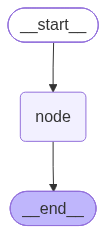

In [4]:
from IPython.display import Image,display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

调用

In [5]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages":[HumanMessage("你好啊，我是红狼！")]
})
result

{'messages': [HumanMessage(content='你好啊，我是红狼！', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好，我是节点1', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 1}

# 使用pretty_print来格式化显示
***

In [6]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages":[HumanMessage("你好啊，我是红狼！")]
})
for messages in result["messages"]:
    messages.pretty_print()

================================ Human Message =================================

你好啊，我是红狼！
================================== Ai Message ==================================

你好，我是节点1


串行控制
****

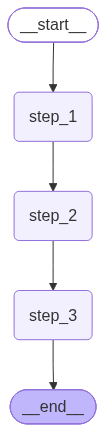

In [7]:
from typing_extensions import TypedDict
from IPython.display import Image,display
from langgraph.graph import START,StateGraph,END

class State(TypedDict):
    value_1:str
    value_2:str

def step_1(state:State):
    return {"value_1":state["value_1"]}

def step_2(state:State):
    current_value_1 = state["value_1"]
    return {"value_1":f"{current_value_1}+b"}

def step_3(state:State):
    return {"value_2":10}

graph_builder = StateGraph(State)
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START,"step_1")
graph_builder.add_edge("step_1","step_2")
graph_builder.add_edge("step_2","step_3")
graph_builder.add_edge("step_3",END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
graph.invoke({"value_1": "c","value_2":9})

{'value_1': 'c+b', 'value_2': 10}

分支控制
****

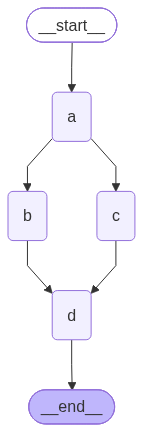

In [9]:
import operator
from typing import Any,Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

#Annotated允许为类型提供额外的元数据，而不影响类型检查起对类型本身的理解
class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"添加“A”到{state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"添加“B”到{state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"添加“C”到{state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"添加“D”到{state['aggregate']}")
    return {"aggregate":["D"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

builder.add_edge(START,"a")
builder.add_edge("a","b")
builder.add_edge("a","c")
builder.add_edge("b","d")
builder.add_edge("c","d")
builder.add_edge("d",END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke({"aggregate":[]},{"configurable":{"thread":"foo"}})

添加“A”到[]
添加“B”到['A']
添加“C”到['A']
添加“D”到['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

条件分支和循环
****

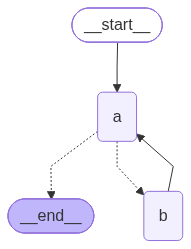

In [11]:
import operator
from typing_extensions import TypedDict
from typing import Annotated,Literal
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"Node A sees {state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"Node B sees {state['aggregate']}")
    return {"aggregate":["B"]}

#Define nodes
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)

#Define edges
def route(state:State) -> Literal["b",END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","a")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"aggregate":[]})

Node A sees []
Node B sees ['A']
Node A sees ['A', 'B']
Node B sees ['A', 'B', 'A']
Node A sees ['A', 'B', 'A', 'B']
Node B sees ['A', 'B', 'A', 'B', 'A']
Node A sees ['A', 'B', 'A', 'B', 'A', 'B']


{'aggregate': ['A', 'B', 'A', 'B', 'A', 'B', 'A']}

使用递归限制recursion_limit来防止异常情况的大量无用调用

In [13]:
from langgraph.errors import GraphRecursionError

try:
    graph.invoke({"aggregate":[]},{"recursion_limit":4})
except GraphRecursionError:
    print("Recursion Error")

Node A sees []
Node B sees ['A']
Node A sees ['A', 'B']
Node B sees ['A', 'B', 'A']
Recursion Error


循环

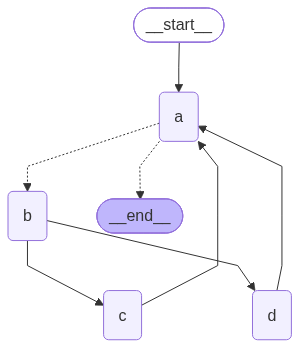

In [14]:
import operator
from typing import Any,Annotated,Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

#Annotated允许为类型提供额外的元数据，而不影响类型检查起对类型本身的理解
class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"Node A sees {state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"Node B sees {state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"Node C sees {state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"Node D sees {state['aggregate']}")
    return {"aggregate":["D"]}

#节点
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

#边
def route(state:State) -> Literal["b",END]:
    if len(state["aggregate"])<7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","c")
builder.add_edge("b","d")
builder.add_edge(["c","d"],"a")
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
result = graph.invoke({"aggregate": []})


Node A sees []
Node B sees ['A']
Node C sees ['A', 'B']
Node D sees ['A', 'B']
Node A sees ['A', 'B', 'C', 'D']
Node B sees ['A', 'B', 'C', 'D', 'A']
Node C sees ['A', 'B', 'C', 'D', 'A', 'B']
Node D sees ['A', 'B', 'C', 'D', 'A', 'B']
Node A sees ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D']


图的运行时配置
****

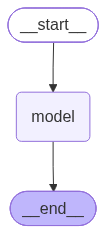

In [16]:
import operator
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
import os
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import END, StateGraph, START

model = ChatDeepSeek(
    model="Pro/deepseek-ai/DeepSeek-V3",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

model1 = ChatOpenAI(
    model="ByteDance-Seed/Seed-OSS-36B-Instruct",
    temperature=0,
    api_key=os.environ.get("OPENAI_API_KEY"),
    base_url=os.environ.get("OPENAI_API_BASE"),
)

# 定义要切换的模型
models = {
    "deepseek": model,
    "openai": model1,
}

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

def _call_model(state:AgentState,config:RunnableConfig):
    #使用LCEL的模型
    model_name = config["configurable"].get("model", "deepseek")
    model = models[model_name]
    response = model.invoke(state["messages"])
    return {"messages":[response]}

#define a new graph
builder = StateGraph(AgentState)
builder.add_node("model",_call_model)
builder.add_edge(START, "model")
builder.add_edge("model", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

没有增加运行配置的情况下，默认使用seepseek

In [17]:
graph.invoke({"messages":[HumanMessage(content="hi,你是谁？")]})

{'messages': [HumanMessage(content='hi,你是谁？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好呀！😊我是DeepSeek Chat，由深度求索公司创造的智能AI助手。我可以帮你解答问题、提供建议、陪你聊天，甚至帮你处理各种文本和文件！有什么我可以帮你的吗？✨', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 7, 'total_tokens': 54, 'completion_tokens_details': None, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 7}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a0664737c1d8f8c00747334bd76306', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06647-35b8-7c93-bdfd-18e97582bc93-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 47, 'total_tokens': 54, 'input_token_details': {'cache_read': 0}, 'output_

增加运行时配置，动态切换模型

In [18]:
config = {"configurable":{"model":"openai"}}
graph.invoke({"messages":[HumanMessage(content="hi,你是谁？")]},config=config)

{'messages': [HumanMessage(content='hi,你是谁？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hi～我是豆包，是字节跳动开发的人工智能，能帮你回答问题、提供信息，也能陪你闲聊哦～', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 270, 'prompt_tokens': 13, 'total_tokens': 283, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 240, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 13}, 'model_provider': 'openai', 'model_name': 'ByteDance-Seed/Seed-OSS-36B-Instruct', 'system_fingerprint': '', 'id': '01a0664740e8433d4b74f27fa6fd8839', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06647-3f5d-76a3-80d0-078fd6269610-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

# MapRedude并执行
****
给定一个来自用户的一般主题，生成相关主题列表，为每个主题生成一个笑话，并从结果列表中选择最佳笑话
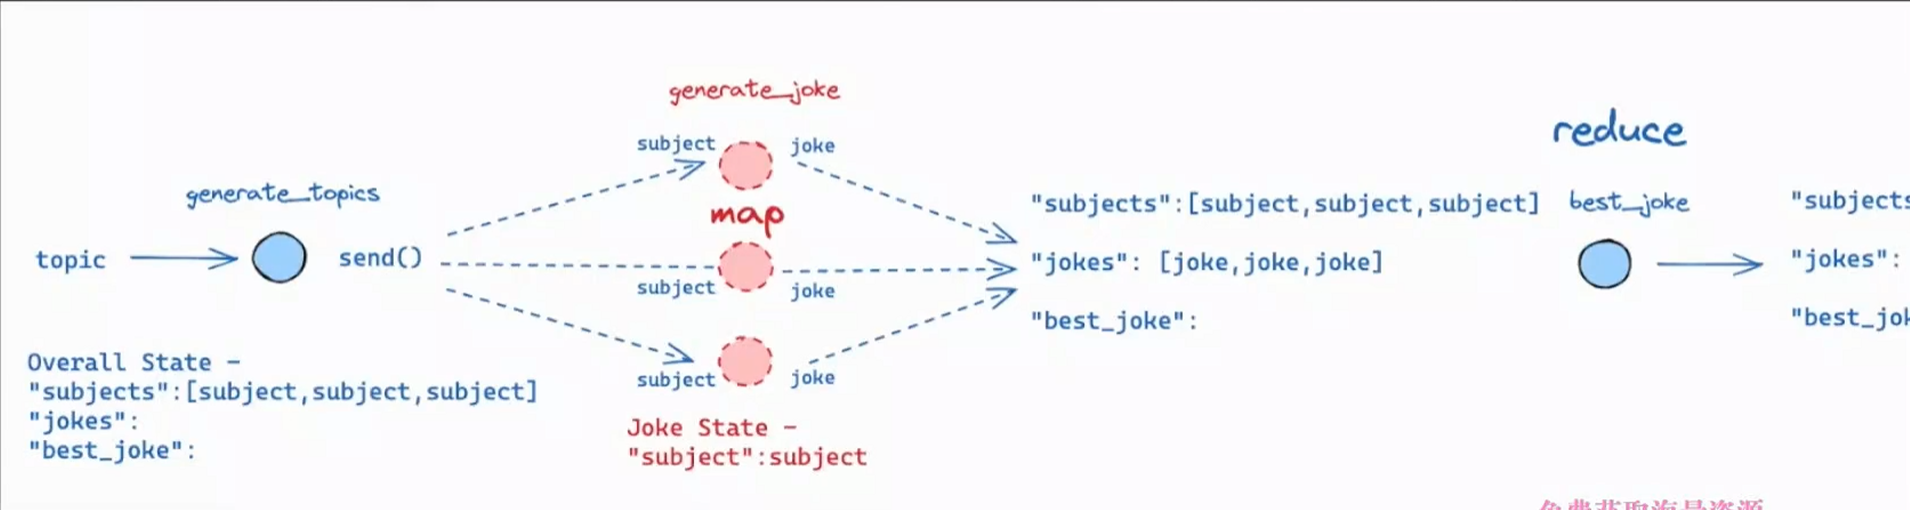

In [19]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.types import Send
from langgraph.graph import END, StateGraph, START
from pydantic import BaseModel,Field
import os

#模型和提示词
#定义我们将使用的模型和提示词
subject_prompt = """生成一个逗号分隔的列表，包含2到5个与以下主题有关的例子：{topic}。"""
joke_prompt = """生成一个关于{subject}的笑话"""
best_joke_prompt = """以下是一些关于{topic}的笑话。选出最好的一个！返回最佳笑话的ID。

{{"jokes"}}"""

class Subjects(BaseModel):
    subjects:list[str]

class Joke(BaseModel):
    joke:str

class BestJoke(BaseModel):
    id: int = Field(description="最佳的笑话索引，从0开始",ge=0)

model=ChatDeepSeek(
    model="Pro/deepseek-ai/DeepSeek-V3",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

#这将是主图的整体状态
#它将包含一个主题（我们期望用户提供）
#然后它将生成一个主题列表，并为每一个主题生成一个笑话
class OverallState(TypedDict):
    topic:str
    subjects:list
    #注意这里我们使用oprator.add
    #这是因为我们想把从各个节点生成的所有笑话合并回一个列表-这本质上是“规约”部分
    jokes:Annotated[list,operator.add]
    best_selected_joke:str

#用于生成笑话
class JokeState(TypedDict):
    subject:str

#这是我们用来生成笑话的函数
def generate_topics(state:OverallState):
    prompt=subject_prompt.format(topic=state["topic"])
    response=model.with_structured_output(Subjects).invoke(prompt)
    return {"subjects":response.subjects}

#这里我们根据给定的主题生成笑话
def genrate_joke(state:JokeState):
    prompt=joke_prompt.format(subject=state["subject"])
    response=model.with_structured_output(Joke).invoke(prompt)
    return {"jokes":[response.joke]}

#这里我们定义映射到生成的主题上的逻辑
#我们将在图中使用这个作为边缘
def continue_to_jokes(state:OverallState):
    #我们将返回一个'send'对象列表
    #每个'send'对象包含图中节点的名称
    #以及要发送到该节点的状态
    return [Send("generate_joke", {"subject":s}) for s in state["subjects"]]

#这里我们将评判最佳笑话
def best_joke(state:OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = model.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke":state["jokes"][response.id]}

#构建图，这里我们将所有内容组合在一起构建我们的图
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", genrate_joke)
graph.add_node("best_joke", best_joke)
graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)
app = graph.compile()

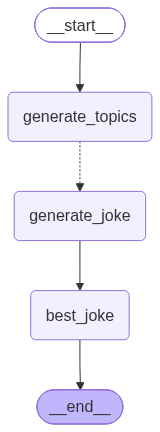

In [20]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [21]:
for s in app.stream({"topic":"曼巴"}):
    print(s)

{'generate_topics': {'subjects': ['曼巴精神', '科比·布莱恩特', '洛杉矶湖人队', 'NBA', '篮球训练']}}
{'generate_joke': {'jokes': ['为什么洛杉矶湖人队的球迷总是带着梯子去看比赛？因为他们总是期待球队能“爬”回巅峰！']}}
{'generate_joke': {'jokes': ["为什么科比·布莱恩特从不玩捉迷藏？因为曼巴精神告诉他：'永远不要隐藏，要进攻！'"]}}
{'generate_joke': {'jokes': ['为什么篮球训练时总是带着梯子？因为教练说我们要“步步高升”！']}}
{'generate_joke': {'jokes': ['为什么科比·布莱恩特总是带着篮球去派对？因为他从不放过任何一个投篮的机会！']}}
{'generate_joke': {'jokes': ['为什么NBA球员不喜欢玩捉迷藏？因为他们总是被“盖帽”！']}}
{'best_joke': {'best_selected_joke': "为什么科比·布莱恩特从不玩捉迷藏？因为曼巴精神告诉他：'永远不要隐藏，要进攻！'"}}


# langgraph-持久化与记忆
****
基本运用：线程隔离的持久化层
基本运用：跨线程持久化调用
记忆：短期记忆的实现
记忆：长期以及实现
记忆：使用总结技术优化记忆

线程隔离的持久化层
****

In [22]:
from langchain_deepseek import ChatDeepSeek
import os
from langgraph.graph import StateGraph,START,MessagesState

model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

def call_model(state:MessagesState):
    response = model.invoke(state["messages"])
    return {"messages":[response]}

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
graph = builder.compile()


没有激活持久化层，无法实现多轮对话

In [23]:
input_message = [{"role": "user", "content": "你好，我是红狼！"}]
for chunk in graph.stream({"messages":input_message},stream_mode="values"):
    chunk["messages"][-1].pretty_print()

input_message = [{"role": "user", "content": "我叫什么名字？"}]
for chunk in graph.stream({"messages":input_message},stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！这个名字听起来很有个性和力量感，像是从冒险故事或游戏中走出来的角色呢～ 😄 今天是想分享什么有趣的经历，还是需要帮忙解决某个“任务”？我随时待命！  

（如果这个名字有特殊含义或来源，比如《合金装备》里的角色，或者你希望我用特定方式称呼你，随时告诉我哦！）
================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

你还没有告诉我你的名字呢！😊 你可以告诉我你的名字，我会记住的～或者，你也可以给自己起个有趣的昵称，比如“小星星”或者“冒险家”之类的！你想让我怎么称呼你呢？


In [24]:
from langgraph.checkpoint.memory import MemorySaver
#使用 MemorySaver 保存中间状态
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

In [25]:
config = {"configurable":{"thread_id":"1"}}
input_message = {"role":"user","content":"你好，我是红狼！"}
for chunk in graph.stream({"messages":[input_message]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！这个名字听起来很有个性和力量感，像是从冒险故事或游戏中走出来的角色呢！😄 有什么特别的故事或原因让你选择这个称呼吗？或者今天有什么想聊的话题？无论是游戏、动漫、户外探险还是其他兴趣，我都很乐意陪你聊聊～ 

（如果真的有《合金装备》或《狼性文化》之类的关联，也可以展开说说哦！）


In [26]:
input_message = {"role": "user", "content": "我叫什么名字？"}
for chunk in graph.stream({"messages":[input_message]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

哈哈，你刚刚已经告诉我啦——你的名字是 **“红狼”**！ 🐺🔴  

如果这是个谜语或者测试……那我可要骄傲地说：**“满分答案，对吧？”** 😎  

（不过如果你有另一个隐藏的“真名”想让我猜，可能需要多给点线索哦～比如：“红狼其实是代号，我的本名和___有关…” 之类的？）  

随时等你“投喂”新信息～ 👂✨


注意thread_id的输入

In [27]:
input_messages = {"role": "user", "content": "我叫什么名字"}
for chunk in graph.stream(
    {"messages":[input_messages]},
    {"configurable":{"thread_id":"2"}},#diffrent thread_id
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什么名字
================================== Ai Message ==================================

你还没有告诉我你的名字呢！😊 你可以告诉我你的名字，我会记住并用来称呼你～或者，如果你希望我帮你起个有趣的名字，也可以告诉我哦！


# 跨线程共享持久化数据
****
使用userid

设置内存记忆

In [28]:
from langgraph.store.memory import InMemoryStore
from langchain_openai import OpenAIEmbeddings
import os
#使用OPENAI的封装，但是运行国产化模型
#使用内存存储来保存向量化后记忆数据
in_memory_store = InMemoryStore(
    index={
        "embed":OpenAIEmbeddings(
            model="Pro/BAAI/bge-m3",
            api_key=os.environ.get("OPENAI_API_KEY"),
            base_url=os.environ.get("OPENAI_API_BASE")
        ),
        "dims":1024,
    }
)

In [29]:
import uuid #使用UUID来生成唯一的线程ID
from typing import Annotated
from typing_extensions import TypedDict

from langchain_deepseek import ChatDeepSeek
import os
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph,MessagesState,START
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

#注意：我们将Store参数传递给节点
#这是我们编译图时使用的Store
def call_model(state:MessagesState,config:RunnableConfig,*,store:BaseStore):
    #从存储中检索用户信息
    user_id = config["configurable"].get("user_id")
    #从存储中检索用户信息
    namespace = ("memories",user_id)
    memories = store.search(namespace,query=str(state["messages"][-1].content))
    info = "\n".join([d.value["data"] for d in memories])
    system_msg = f"你是一个正在与用户交谈的小助手。用户信息{info}"
    print(f"在内存中检索用户信息：{info}")

    #如果用户要求模型记住信息，则存储新的记忆
    last_message = state["messages"][-1]
    if "记住" in last_message.content.lower() or "remenber" in last_message.content.lower():
        #硬编码一个记忆
        memory = "用户名字是红狼"
        store.put(namespace,str(uuid.uuid4()),{"data":memory})

    response = model.invoke(
        [{"role":"system","content":system_msg}] + state["messages"]
    )
    return {"messages":response}

builder = StateGraph(MessagesState)
builder.add_node("call_model",call_model)
builder.add_edge(START,"call_model")

#注意，我们在编译图时传递了store对象
graph = builder.compile(checkpointer=MemorySaver(),store=in_memory_store)

注意线程ID和用户ID

In [30]:
config={"configurable":{"thread_id":1,"user_id":"1"}}
input_message = {"role":"user","content":"请记住我的名字叫红狼!"}
for chunk in graph.stream({"messages":input_message},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

请记住我的名字叫红狼!
在内存中检索用户信息：
================================== Ai Message ==================================

好的，红狼！我会记住你的名字。有什么我可以帮你的吗？😊


跨线程使用相同的用户ID查询

In [31]:
#注意线程ID和用户ID
config={"configurable":{"thread_id":2,"user_id":"1"}}
input_message = {"role":"user","content":"我叫什么名字!"}
for chunk in graph.stream({"messages":input_message},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什么名字!
在内存中检索用户信息：用户名字是红狼
================================== Ai Message ==================================

你的名字是红狼！有什么我可以帮你的吗，红狼？


我们可以查询存储在内存中的记忆

In [32]:
for memory in in_memory_store.search(("memories","1")):
    print(memory.value)

{'data': '用户名字是红狼'}


用户级的记忆隔离

In [33]:
config={"configurable":{"thread_id":3,"user_id":"2"}}
input_message = {"role":"user","content":"我叫什么名字!"}
for chunk in graph.stream({"messages":input_message},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什么名字!
在内存中检索用户信息：
================================== Ai Message ==================================

哈哈，看来你考到我了！目前我还不知道你的名字呢～不过如果你愿意告诉我，我就可以记住啦！或者你希望我给你起个有趣的临时昵称？😄  

（当然，作为AI助手，我其实不会长期保留个人信息哦，隐私安全是第一位的～）


**短期记忆的实现**
****
*基于最简单的ReAct智能体

In [34]:
from typing import Literal

from langchain_deepseek import ChatDeepSeek
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState,StateGraph,START,END
from langgraph.prebuilt import ToolNode

#使用内存存储来读取记忆
memory=MemorySaver()

@tool
def search(query:str):
    """调用此函数可以浏览网络"""
    #模拟一个网络搜索并返回
    return "北京天气晴朗 大约22度 湿度30%"

tools=[search]
tool_node = ToolNode(tools)
model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)
bound_model = model.bind_tools(tools)

def should_continue(state:MessagesState):
    """返回下一个要执行的节点"""
    last_messages = state["messages"][-1]
    #如果没有函数调用，则结束
    if not last_messages.tool_calls:
        return END
    #否则如果有，我们继续
    return "action"

#定义调用模型的函数
def call_model(state:MessagesState):
    response = bound_model.invoke(state["messages"])
    #我们返回一个列表，因为这会被添加到现有列表中
    return {"messages":response}

#定义一个圈
workflow = StateGraph(MessagesState)

#定义我们将在其间循环的两个节点
workflow.add_node("agent",call_model)
workflow.add_node("action",tool_node)

#将入口点设置为‘agent’
#这意味着这个节点是第一个被调用的
workflow.add_edge(START,"agent")

#现在我们添加一个条件边
workflow.add_conditional_edges(
    #首先，我们定义起始节点，我们使用‘agent’
    #这意味着这些是在‘agent’节点被调用后采取的边。
    "agent",
    #接下来，我们传入将确定下一个调用哪个节点的函数
    should_continue,
    #接下来，我们传入路径映射 - 这条边可能去往的所有节点
    ["action",END],
)

#现在我们从‘tools’到‘agent’添加一个普通边。
#这意味着在调用‘tools’之后，接下来调用‘agent’节点。
workflow.add_edge("action","agent")

#最后，我们编译它！
#这将它编译成一个 LangChain Runnable
# 这意味着你可以像使用任何其他 runnable 一样使用它
# 设置检查点为内存形式，注意有没有设置store
app = workflow.compile(checkpointer=memory)

调用图

In [35]:
from langchain_core.messages import HumanMessage

config={"configurable":{"thread_id":20}}
input_message = HumanMessage(content="你好，我是红狼！")
for event in app.stream({"messages":input_message},config,stream_mode="values"):
    event["messages"][-1].pretty_print()

input_message = HumanMessage(content="我叫什么名字？")
for event in app.stream({"messages":input_message},config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！很高兴认识你！有什么可以帮你的吗？
================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

你刚才告诉我你的名字是“红狼”！需要我帮你做些什么吗？


# 长期记忆
****
- 使用MongDB

- 在本地安装MongoDB
- windows（已选择）：

In [36]:
#安装后，启动MongoDB服务
#通常安装后会自动设置为系统服务并启动
#如果没有自动启动，可以在命令行提示符中运行：
#net start MongoDB

- macos

In [37]:
#安装
# brew tap mongodb/brew
# brew install mongodb-community

#启动服务
# brew services start mongodb-community

- 使用docker快速安装

In [38]:
# 拉取MongDB镜像
# docker pull docker.1ms.ioo/mongo

#运行MongDB容器
# docker run -d -p 27017:27017 --name mongdb mongo

#验证容器是否运行
# docker ps

连接mongodb

In [39]:
! pip install -U pymongo langgraph langgraph-checkpoint-mongodb

  Using cached pymongo-4.17.0-cp310-cp310-win_amd64.whl (815 kB)



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


测试MongoDB连接

In [40]:
import pymongo

#创建MongoDB客户端连接
cilent = pymongo.MongoClient("mongodb://localhost:27017/")

#测试连接
try:
    cilent.admin.command('ping')
    print("MongoDB连接成功！")
except Exception as e:
    print(f"MongoDB连接失败:{e}")

MongoDB连接成功！


创建一个最简单的智能体

In [41]:
from typing import Literal

from langchain_core.tools import tool
from langchain_deepseek import ChatDeepSeek
from langgraph.prebuilt import create_react_agent

@tool
def get_weather(city:Literal["北京","深圳"]):
    """用来返回天气信息的工具函数"""
    if city == "北京":
        return "北京天气晴朗 大约22度 湿度30%"
    elif city == "深圳":
        return "深圳天气多云 大约28度 湿度80%"
    else:
        raise AssertionError("Unknown city")

tools = [get_weather]
model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

连接mongodb进行查询

In [42]:
from langgraph.checkpoint.mongodb import MongoDBSaver

MONGODB_URI = "localhost:27017" #replace this with your connection string

with MongoDBSaver.from_conn_string(MONGODB_URI) as checkpointer:
    graph = create_react_agent(model,tools=tools,checkpointer=checkpointer)
    config = {"configurable":{"thread_id":"1"}}
    response = graph.invoke(
        {"messages":[("human","北京今天的天气如何？")]},config
    )


C:\Users\31354\AppData\Local\Temp\ipykernel_39728\3326755007.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = create_react_agent(model,tools=tools,checkpointer=checkpointer)


In [43]:
print(response)

{'messages': [HumanMessage(content='北京今天的天气如何？', additional_kwargs={}, response_metadata={}, id='b2f27350-def2-4b9f-ad72-d9ae6bd21db1'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 100, 'total_tokens': 119, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 100}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a06134d4663a6b0082b8683a6d5626', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06134-d35f-7773-9316-f2ec0034d728-0', tool_calls=[{'name': 'get_weather', 'args': {'city': '北京'},

### 优化记忆
****
- 消息过滤：对旧消息进行类似删除或编辑的操作，目的是为了防止撑爆上下文
- 消息总结：对旧消息进行总结，目的一样是为了防止记忆内容过长
- 注意对记忆的管理是一项关于召回率和精度的平衡艺术

In [44]:
from typing import Literal

from langchain_deepseek import ChatDeepSeek
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState,StateGraph,START
from langgraph.prebuilt import ToolNode

memory = MemorySaver()

@tool
def search(query:str):
    """调用此函数可以浏览网络"""
    #模拟一个网络搜索并返回
    return "北京天气晴朗 大约22度 湿度30%"

tools=[search]
tool_node = ToolNode(tools)
model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)
bound_model = model.bind_tools(tools)

def should_continue(state:MessagesState):
    """返回下一个要执行的节点"""
    last_messages = state["messages"][-1]
    #如果没有函数调用，则结束
    if not last_messages.tool_calls:
        return END
    #否则如果有，我们继续
    return "action"

def filter_messages(messages:list):
    #这是一个非常简单的辅助函数，它只使用最后一条消息
    return messages[-1:]

#定义调用模型的函数
def call_model(state:MessagesState):
    messages = filter_messages(state["messages"])
    response = bound_model.invoke(messages)
    #我们返回一个列表，因为这会被添加到现有列表中
    return {"messages":response}

#定义一个圈
workflow = StateGraph(MessagesState)

#定义我们将在其间循环的两个节点
workflow.add_node("agent",call_model)
workflow.add_node("action",tool_node)

#将入口点设置为‘agent’
#这意味着这个节点是第一个被调用的
workflow.add_edge(START,"agent")

#现在添加一个条件边
workflow.add_conditional_edges(
    #首先，我们定义起始节点，我们使用‘agent’
    #这意味着这些是在‘agent’节点被调用后采取的边。
    "agent",
    #接下来，我们传入将确定下一个调用哪个节点的函数
    should_continue,
    #接下来，我们传入路径映射 - 这条边可能去往的所有节点
    ["action",END],
)

#现在我们从‘action’到‘agent’添加一个普通边。
#这意味着在调用‘action’之后，接下来调用‘agent’节点。
workflow.add_edge("action","agent")

#最后，我们编译它！
#这将它编译成一个 LangChain Runnable
# 这意味着你可以像使用任何其他 runnable 一样使用它
# 设置检查点为内存形式，注意有没有设置store
app = workflow.compile(checkpointer=memory)

进行调用，由于进行了消息裁剪，所以即便使用了memory，依然无法记住过往对话

In [45]:
from langchain_core.messages import HumanMessage

config={"configurable":{"thread_id":2}}
input_message = HumanMessage(content="你好，我是红狼！")
for event in app.stream({"messages":input_message},config,stream_mode="values"):
    event["messages"][-1].pretty_print()

#注意，我们在这里使用了一个辅助函数，它只使用最后一条消息
#这将导致我们的模型只看到最后一条消息
input_message = HumanMessage(content="我叫什么名字？")
for event in app.stream({"messages":input_message},config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！很高兴认识你！有什么我可以帮你的吗？
================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

我无法知道你的名字，因为我没有存储或记忆个人信息的功能。你可以告诉我你的名字，我会在本次对话中记住并使用它！


使用对话总结技术在实战中更为常见

In [46]:
from typing import Literal

from langchain_deepseek import ChatDeepSeek
from langchain_core.messages import SystemMessage,RemoveMessage,HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState,StateGraph,START,END

memory = MemorySaver()

#我们将添加一个‘summary’属性（除了MessagesState已有的‘messages’键之外）
class State(MessagesState):
    summary:str

#我们将使用这个模型进行对话和总结
model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

#定义调用模型的逻辑
def call_model(state:MessagesState):
    #如果存在摘要，我们将其作为系统消息添加
    summary = state.get("summary","")
    if summary:
        system_message = f"之前对话的摘要：{summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    response = model.invoke(messages)
    #我们返回一个列表，因为这将被添加到现有列表中
    return {"messages":[response]}

#现在我们定义确定是结束还是总结对话的逻辑
def should_continue(state:State) -> Literal["summarize_conversation",END]:
    """返回下一个要执行的节点"""
    messages = state["messages"]
    #如果消息超过六条，则我们总结对话
    if len(messages)>6:
        return "summarize_conversation"
    #否则我们可以直接结束
    return END

def summarize_conversation(state:State):
    #首先，我们总结对话
    summary = state.get("summary","")
    if  summary:
        #如果已经存在摘要，我们要使用不用的系统提示来总结它
        #与没有摘要的情况不同
        summary_message = (
            f"这是迄今为止对话的摘要：{summary}\n\n"
            "考虑上面的新消息，扩展需要"
        )
    else:
        summary_message = "创建上述对话的摘要："

    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    #现在我们需要删除我们不再想显示的消息
    #我将删除除最后两条以外的所有消息，但你可以更改这一点
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content,"messages":delete_messages}

#定义一个新图
workflow = StateGraph(State)

#定义对话节点和总结节点
workflow.add_node("conversation",call_model)
workflow.add_node(summarize_conversation)

#将入口点设置为对话
workflow.add_edge(START,"conversation")

#现在添加一个条件边
workflow.add_conditional_edges(
    #首先，我们定义起始节点。我们使用‘conversation'
    #这意味着这些是在调用’conversation‘节点后采取的边
    "conversation",
    #接下来，我们传入将确定下一个调用哪个节点的函数
    should_continue,
)

#现在我们从‘summarize_conversation’到END添加一个普通边。
#这意味着在调用‘summarize_conversation‘之后，我们结束。
workflow.add_edge("summarize_conversation",END)

#最后，我们编译它
app = workflow.compile(checkpointer=memory)


升级一下print函数以便可以更清晰的看到记忆过程

In [47]:
def print_update(update):
    for k,v in update.items():
        for m in v["messages"]:
            m.pretty_print()
        if "summary" in v:
            print(v["summary"])

In [48]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id":"4"}}
input_message = HumanMessage(content="你好，我是红狼！")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

input_message = HumanMessage(content="我叫什么名字?")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)
    
input_message = HumanMessage(content="我喜欢玩三角洲！")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！这个名字听起来很有个性和力量感，像是从冒险故事或游戏中走出来的角色呢～ 😄 今天有什么想聊的？是准备组队打Boss，还是想分享什么有趣的经历？
================================ Human Message =================================

我叫什么名字?
================================== Ai Message ==================================

哈哈，你刚刚已经告诉我啦——你叫**“红狼”**！这个名字我可不会忘，毕竟又酷又带点神秘感，像荒野里的独行侠或者某个传奇代号呢～ 🔥  

（如果这是昵称或游戏ID，需要我记住其他称呼的话，随时告诉我哦！）
================================ Human Message =================================

我喜欢玩三角洲！
================================== Ai Message ==================================

哈哈，**三角洲**（Delta Force）！经典啊！🌍🔫 那个硬核的战术射击味儿，现在玩起来还是超带感——尤其是隐蔽行动和远距离狙杀的刺激，懂的都懂！  

你最喜欢哪一作？是老派的《三角洲部队》经典系列，还是最近新出的《三角洲行动》（Delta Force: Hawk Ops）？要是组队缺队友，我虽然没法实操，但可以给你脑补战术支援哦～ 😎  

（顺便问下，你玩的时候是“莽夫冲锋派”还是“伏地魔狙击流”？）


未达到总结阈值

In [49]:
values = app.get_state(config).values
values

{'messages': [HumanMessage(content='你好，我是红狼！', additional_kwargs={}, response_metadata={}, id='ac633d17-0f9f-47ee-bbbc-3040bfe1a69f'),
  AIMessage(content='你好，红狼！这个名字听起来很有个性和力量感，像是从冒险故事或游戏中走出来的角色呢～ 😄 今天有什么想聊的？是准备组队打Boss，还是想分享什么有趣的经历？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 9, 'total_tokens': 57, 'completion_tokens_details': None, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 9}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a0664b5ffe17c329f6e02b998c9022', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0664b-5ea1-79a0-8a73-7ffb508d3fb5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 48, 'total_tokens': 57, 'input_token_

In [50]:
input_message = HumanMessage(content="我更喜欢羽毛球！")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

我更喜欢羽毛球！
================================== Ai Message ==================================

哈哈，从**三角洲**的枪林弹雨切换到**羽毛球**的轻羽飞扬，这画风突变但很带感啊！🏸💨 羽毛球才是真正的“快准狠”对决——扣杀像狙击，网前小球像战术潜伏，体力消耗堪比特种兵训练！  

你平时是**暴力扣杀派**还是**技术控场流**？有没有被队友吐槽过“你这拍子挥出了狙击枪的气势”？ 😂  
（或者…偷偷告诉我，你是不是在球场上用《三角洲》的战术走位迷惑对手？）  

下次约球记得带够水，毕竟羽毛球场的“战场”也是汗水重灾区！ 💦
================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


**对话摘要：**  

1. **自我介绍**：用户以代号“红狼”开场，AI称赞其名字酷炫有故事感，并询问互动意图。  
2. **游戏偏好**：用户提及喜欢战术射击游戏《三角洲》，AI呼应经典玩法，讨论系列作品及

查看对话记录

In [51]:
values = app.get_state(config).values
values

{'messages': [HumanMessage(content='我更喜欢羽毛球！', additional_kwargs={}, response_metadata={}, id='1e584567-a241-4d1e-ae0d-5117f797e831'),
  AIMessage(content='哈哈，从**三角洲**的枪林弹雨切换到**羽毛球**的轻羽飞扬，这画风突变但很带感啊！🏸💨 羽毛球才是真正的“快准狠”对决——扣杀像狙击，网前小球像战术潜伏，体力消耗堪比特种兵训练！  \n\n你平时是**暴力扣杀派**还是**技术控场流**？有没有被队友吐槽过“你这拍子挥出了狙击枪的气势”？ 😂  \n（或者…偷偷告诉我，你是不是在球场上用《三角洲》的战术走位迷惑对手？）  \n\n下次约球记得带够水，毕竟羽毛球场的“战场”也是汗水重灾区！ 💦', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 144, 'prompt_tokens': 272, 'total_tokens': 416, 'completion_tokens_details': None, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 272}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a0664b8c7e663e46264407430cdac1', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0664b-8b5f-

此时由于总结中附带了过往的核心消息，所以我们依然可以进行记忆回顾

In [52]:
input_message = HumanMessage(content="我叫什么名字？")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

哈哈，看来我刚刚被**「三角洲模式」**带跑偏了！ 🤖💥 你当然没有公开过名字——不过如果你想让我用某种画风称呼你，随时可以下令！比如：  

*「代号：羽球刺客」🎭🏸  
*「隐藏ID：扣杀终结者」💥  
*「系统默认：人类朋友」👋  

（或者…悄悄告诉我你的真名？我保证不会像游戏里的NPC一样乱喊！） 😉


### 审查工具调用
****
人工介入智能体的工具调用过程，实现人机协同

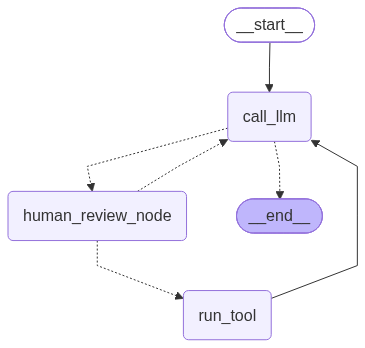

In [53]:
from typing_extensions import TypedDict, Literal
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from langchain_core.tools import tool
from langchain_core.messages import AIMessage
from IPython.display import Image, display

@tool
def weather_search(city:str):
    """搜索天气"""
    print("---")
    print(f"正在搜索:{city}")
    print("---")
    return "晴朗！"

#设置模型
from langchain_deepseek import ChatDeepSeek
import os

deepseek = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

model = deepseek.bind_tools(
    [weather_search]
)

class State(MessagesState):
    """简单状态"""

def call_llm(state):
    return {"messages":[model.invoke(state["messages"])]}

def human_review_node(state) -> Command[Literal["call_llm","run_tool"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    #这是我们将通过Command(rsult=<human_review>)提供的值
    human_review = interrupt(
        {
            "question":"这是正确的吗？",
            #显示工具调用以供审核
            "tool_call":tool_call,
        }
    )

    review_action = human_review["action"]
    review_data = human_review.get("data")

    #如果批准，调用工具
    if review_action == "continue":
        return Command(goto="run_tool")

    #更新AI消息并调用工具
    elif review_action == "update":
        updated_message = {
            "role":"ai",
            "content":last_message.content,
            "tool_calls":[
                {
                    "id":tool_call["id"],
                    "name":tool_call["name"],
                    #这是人类提供的更新
                    "args":review_data,
                }
            ],
            #这很重要 - 这需要与你替换的消息相同！
            #否则，它将显示为一个单独的消息
            "id":last_message.id,
        }
        return Command(goto="call_llm", update={"messages":[updated_message]})

    #向LLM提供反馈
    elif review_action == "feedback":
        # 注意:我们将反馈消息添加为TooMessage
        # 以保持消息历史中的正确顺序
        # (带有工具调用的AI消息需要后跟工具调用消息)
        tool_message = {
            "role":"tool",
            # 这是我们的自然语言反馈
            "content":review_data,
            "name":tool_call["name"],
            "tool_call_id":tool_call["id"],
        }
        return Command(goto="call_llm", update={"messages":[tool_message]})

def run_tool(state):
    new_messages = []
    tools = {"weather_search":weather_search}
    tool_calls = state["messages"][-1].tool_calls
    for tool_call in tool_calls:
        tool = tools[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        new_messages.append(
            {
                "role":"tool",
                "name":tool_call["name"],
                "content":result,
                "tool_call_id":tool_call["id"]
            }
        )
        return {"messages":new_messages}

def route_after_llm(state) -> Literal[END,"human_review_node"]:
    if len(state["messages"][-1].tool_calls) == 0:
        return END
    else:
        return "human_review_node"

builder = StateGraph(State)
builder.add_node(call_llm)
builder.add_node(run_tool)
builder.add_node(human_review_node)
builder.add_edge(START,"call_llm")
builder.add_conditional_edges("call_llm",route_after_llm)
builder.add_edge("run_tool","call_llm")

#设置内存
memory = MemorySaver()

#添加
graph = builder.compile(checkpointer=memory)

#查看
display(Image(graph.get_graph().draw_mermaid_png()))

当不涉及工具调用的时候，不会触发人工审核

In [54]:
#Input
initial_input = {"messages": [{"role": "user", "content": "你好！"}]}

# Thread
thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

{'call_llm': {'messages': [AIMessage(content='你好！有什么可以帮您的吗？😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 82, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 82}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a0664bf8c720f1fe443e0b96fdb05a', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0664b-f610-7703-b3bb-7405d80628df-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 82, 'output_tokens': 10, 'total_tokens': 92, 'input_token_details': {'cache_read': 0}, 'output

一旦涉及到工具调用，就会触发人工介入

In [55]:
#Input
initial_input = {"messages": [{"role":"user", "content": "北京的天气如何?"}]}

#Thread
thread = {"configurable": {"thread_id": "2"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

{'call_llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 84, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 84}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a0664bfd5e4647e89a001d10e36173', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0664b-fc48-7620-a97d-620f328e5d3c-0', tool_calls=[{'name': 'weather_search', 'args': {'city': '北京'}, 'id': '01a0664c023bc9659f40f0a26543129d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inp

使用Command进行人机交互

In [56]:
for event in graph.stream(
    # 输入值
    Command(resume={"action":"continue"}),
    thread,
    stream_mode="updates",
    ):
    print(event)
    print("\n")


{'human_review_node': None}


---
正在搜索:北京
---
{'run_tool': {'messages': [{'role': 'tool', 'name': 'weather_search', 'content': '晴朗！', 'tool_call_id': '01a0664c023bc9659f40f0a26543129d'}]}}


{'call_llm': {'messages': [AIMessage(content='北京的天气是晴朗的！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 112, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 112}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a0664c030fd12fad3190f7cf692cdd', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0664c-01cc-7e

更进一步，对智能体调用的工具进行参数编辑

In [57]:
#Input
initial_input = {"messages":[{"role":"user","content":"深圳的天气如何？"}]}

#Thread
thread = {"configurable":{"thread_id":"3"}}

for event in graph.stream(initial_input,thread,stream_mode="updates"):
    print(event)
    print("\n")

{'call_llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 85, 'total_tokens': 103, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 85}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a0664c0804108e4febb50074b56577', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0664c-06ed-7a43-90dc-e08209b22cca-0', tool_calls=[{'name': 'weather_search', 'args': {'city': '深圳'}, 'id': '01a0664c0bb36e70eeff6ac72a7b66f4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inp

In [58]:
#直接对工具的参数进行编辑
for event in graph.stream(
    Command(resume={"action":"update","data":{"city":"上海，中国"}}),
    thread,
    stream_mode="updates"
    ):
    print(event)
    print("\n")

{'human_review_node': {'messages': [{'role': 'ai', 'content': '', 'tool_calls': [{'id': '01a0664c0bb36e70eeff6ac72a7b66f4', 'name': 'weather_search', 'args': {'city': '上海，中国'}}], 'id': 'lc_run--01a0664c-06ed-7a43-90dc-e08209b22cca-0'}]}}


{'call_llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 85, 'total_tokens': 103, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 85}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a0664c0c5194756392fdb00e335eea', 'finish_reason': 'tool_calls', 'lo

### 人机交互 - 对图的状态进行编辑
****
使用断点对节点间的消息进行人工干预
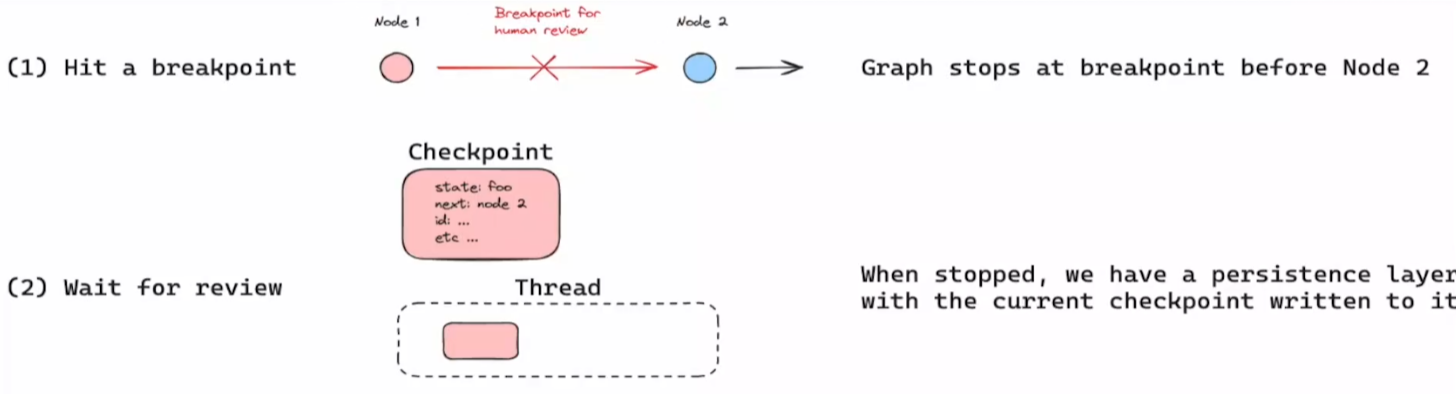
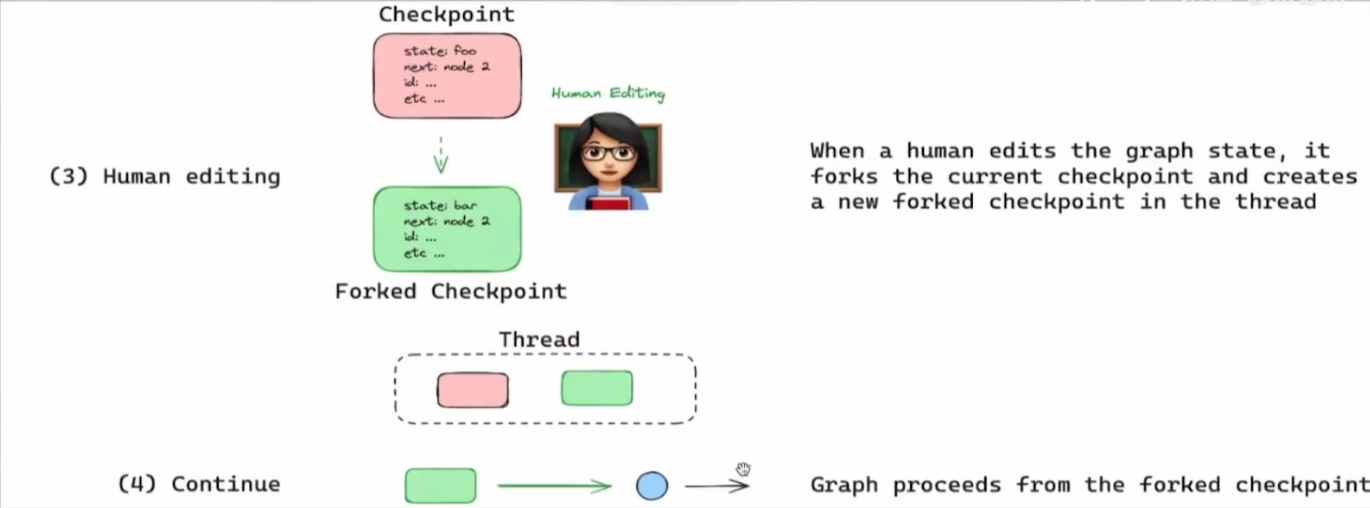

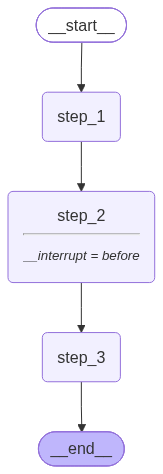

In [59]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image,display

class State(TypedDict):
    input:str

def step_1(state):
    print("---step_1---")
    pass

def step_2(state):
    print("---step_2---")
    pass

def step_3(state):
    print("---step_3")
    pass

builder = StateGraph(State)
builder.add_node("step_1",step_1)
builder.add_node("step_2",step_2)
builder.add_node("step_3",step_3)
builder.add_edge(START,"step_1")
builder.add_edge("step_1","step_2")
builder.add_edge("step_2","step_3")
builder.add_edge("step_3",END)

#set up memory
memory = MemorySaver()

#Add 注意interrupt_before
graph = builder.compile(checkpointer=memory,interrupt_before=["step_2"])

#view
display(Image(graph.get_graph().draw_mermaid_png()))

In [60]:
#Input
initial_input = {"input":"你好！"}

#Thread
thread = {"configurable":{"thread_id":"1"}}

#Run the graph until the first interruption
for event in graph.stream(initial_input,thread,stream_mode="values"):
    print(event)

{'input': '你好！'}
---step_1---


此时可以人工介入

In [61]:
graph.update_state(thread,{"input":"你好 1goto.ai!"})
print("---\n---Updated state!")
print(graph.get_state(thread).values)

---
---Updated state!
{'input': '你好 1goto.ai!'}


In [62]:
#继续执行
for event in graph.stream(None,thread,stream_mode="values"):
    print(event)

{'input': '你好 1goto.ai!'}
---step_2---
---step_3


### langgraph-时光旅行
****
- 重放
- 分叉
- 注意经过实际测试deepseek的tool callling能力还是不如openai

In [63]:
#设置工具
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import MessagesState, START
from langgraph.prebuilt import ToolNode
from langgraph.graph import END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

@tool
def play_song_on_qq(song:str):
    """在QQ音乐上播放歌曲"""
    #调用QQ音乐 API...
    return f"成功在QQ音乐上播放了{song}"

@tool
def play_song_on_163(song: str):
    """在网易云上播放歌曲"""
    # 调用网易云 API...
    return f"成功在网易云上播放了{song}!"


tools = [play_song_on_qq, play_song_on_163]
tool_node = ToolNode(tools)

# 设置模型
from langchain_openai import ChatOpenAI
import os

deepseek = ChatOpenAI(
    model="moonshotai/Kimi-K2.7-Code",
    temperature=0,
    api_key=os.environ.get("OPENAI_API_KEY"),
    base_url=os.environ.get("OPENAI_BASE_URL"),
)

model = deepseek.bind_tools(tools, parallel_tool_calls=False)

#定义节点和条件边

#定义确定是否继续的函数
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    # 如果没有函数调用，则结束
    if not last_message.tool_calls:
        return "end"
    # 否则如果有，我们继续
    else:
        return "continue"


# 定义调用模型的函数
def call_model(state):
    messages = state["messages"]
    response = model.invoke(messages)
    # 我们返回一个列表，因为这将被添加到现有列表中
    return {"messages": [response]}

# 定义一个新图
workflow = StateGraph(MessagesState)

# 定义我们将循环的两个节点
workflow.add_node("agent", call_model)
workflow.add_node("action", tool_node)

# 将入口点设置为`agent`
# 这意味着这个节点是第一个被调用的
workflow.add_edge(START, "agent")

# 现在添加一个条件边
workflow.add_conditional_edges(
    # 首先，我们定义起始节点。我们使用`agent`。
    # 这意味着这些是在调用`agent`节点后采取的边。
    "agent",
    # 接下来，我们传入将确定下一个调用哪个节点的函数。
    should_continue,
    # 最后我们传入一个映射。
    # 键是字符串，值是其他节点。
    # END是一个特殊节点，标记图应该结束。
    # 将会发生的是我们调用`should_continue`，然后该函数的输出
    # 将与此映射中的键匹配。
    # 根据匹配的键，然后调用相应的节点。
    {
        # 如果是`tools`，则调用工具节点。
        "continue": "action",
        # 否则我们结束。
        "end": END,
    },
    )

# 现在我们从`tools`到`agent`添加一个普通边。
# 这意味着在调用`tools`之后，下一步调用`agent`节点。
workflow.add_edge("action", "agent")

# 设置内存
memory = MemorySaver()

# 最后，我们编译它！
# 这将它编译成一个LangChain Runnable，
# 意味着你可以像使用任何其他runnable一样使用它

# 我们添加`interrupt_before=["action"]`
# 这将在调用`action`节点之前添加一个断点
app = workflow.compile(checkpointer=memory)


进行简单交互，要求播放李荣浩的歌曲

In [64]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}
input_message = HumanMessage(content="你能播放一首李荣浩播放量最高的歌曲吗?")
for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

你能播放一首李荣浩播放量最高的歌曲吗?
================================== Ai Message ==================================
Tool Calls:
  play_song_on_qq (functions.play_song_on_qq:0)
 Call ID: functions.play_song_on_qq:0
  Args:
    song: 年少有为 李荣浩
================================= Tool Message =================================
Name: play_song_on_qq

成功在QQ音乐上播放了年少有为 李荣浩
================================== Ai Message ==================================

我已经在QQ音乐上为你播放了李荣浩的热门歌曲《年少有为》，这是他播放量最高的代表作之一。希望你喜欢！🎵


查看记录并重放

In [65]:
app.get_state(config).values["messages"]

[HumanMessage(content='你能播放一首李荣浩播放量最高的歌曲吗?', additional_kwargs={}, response_metadata={}, id='140b3f2b-8305-442d-8ce8-4082d307349a'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 160, 'prompt_tokens': 92, 'total_tokens': 252, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 135, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 92}, 'model_provider': 'openai', 'model_name': 'moonshotai/Kimi-K2.7-Code', 'system_fingerprint': '', 'id': '01a0664c18b816f1a03642658f5196be', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0664c-1713-7cc1-bc58-08b6ed21725b-0', tool_calls=[{'name': 'play_song_on_qq', 'args': {'song': '年少有为 李荣

In [66]:
all_states = []
for state in app.get_state_history(config):
    print(state)
    all_states.append(state)
    print("--")

StateSnapshot(values={'messages': [HumanMessage(content='你能播放一首李荣浩播放量最高的歌曲吗?', additional_kwargs={}, response_metadata={}, id='140b3f2b-8305-442d-8ce8-4082d307349a'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 160, 'prompt_tokens': 92, 'total_tokens': 252, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 135, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 92}, 'model_provider': 'openai', 'model_name': 'moonshotai/Kimi-K2.7-Code', 'system_fingerprint': '', 'id': '01a0664c18b816f1a03642658f5196be', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0664c-1713-7cc1-bc58-08b6ed21725b-0', tool_calls=[{'name': 'play_song_

我们可以返回任何一个状态节点，并从那个时候重新开始操作

In [67]:
to_replay = all_states[2]

In [68]:
to_replay.values

{'messages': [HumanMessage(content='你能播放一首李荣浩播放量最高的歌曲吗?', additional_kwargs={}, response_metadata={}, id='140b3f2b-8305-442d-8ce8-4082d307349a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 160, 'prompt_tokens': 92, 'total_tokens': 252, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 135, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 92}, 'model_provider': 'openai', 'model_name': 'moonshotai/Kimi-K2.7-Code', 'system_fingerprint': '', 'id': '01a0664c18b816f1a03642658f5196be', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0664c-1713-7cc1-bc58-08b6ed21725b-0', tool_calls=[{'name': 'play_song_on_qq', 'args': {'s

In [69]:
to_replay.next

('action',)

如果想从这个状态节点重播，只需这样

In [70]:
for event in app.stream(None,to_replay.config):
    for v in event.values():
        print(v)

{'messages': [ToolMessage(content='成功在QQ音乐上播放了年少有为 李荣浩', name='play_song_on_qq', id='eb324b12-c2dc-4a14-8c53-3b8c0b68a92f', tool_call_id='functions.play_song_on_qq:0')]}
{'messages': [AIMessage(content='我已经在QQ音乐上为你播放了李荣浩的热门歌曲《年少有为》，这首歌是他播放量最高的代表作之一。希望你喜欢！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 153, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 37, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 128, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 128, 'prompt_cache_miss_tokens': 25}, 'model_provider': 'openai', 'model_name': 'moonshotai/Kimi-K2.7-Code', 'system_fingerprint': '', 'id': '01a0664c2fe10969ec05bd8330c591fc', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0664

### 分叉操作
****
从某个节点进行操作，对执行数据进行分叉

In [71]:
# 修改最后一个消息的工具调用
# 我们将其从`play_song_on_163`更改为`play_song_on_qq`
last_message = to_replay.values["messages"][-1]
last_message.tool_calls[0]["name"] = "play_song_on_qq"

branch_config = app.update_state(
    to_replay.config,
    {"messages": [last_message]},
)


此时整个图的流就进行了分叉处理

In [72]:
for event in app.stream(None, branch_config):
    for v in event.values():
        print(v)

{'messages': [ToolMessage(content='成功在QQ音乐上播放了年少有为 李荣浩', name='play_song_on_qq', id='f1d83318-a951-453d-b32b-70e57c0ebaed', tool_call_id='functions.play_song_on_qq:0')]}
{'messages': [AIMessage(content='我已经在QQ音乐上为你播放了李荣浩的热门歌曲《年少有为》。这首歌是他播放量最高的代表作之一，希望你喜欢！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 153, 'total_tokens': 212, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 32, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 153}, 'model_provider': 'openai', 'model_name': 'moonshotai/Kimi-K2.7-Code', 'system_fingerprint': '', 'id': '01a0664c376205d1c90e0f57c0666474', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0664c-3

### langgraph - 流式输出
****
- 几种不同的传输模式

一个最常见的图

In [73]:
from typing import TypedDict
from langgraph.graph import StateGraph, START

class State(TypedDict):
    topic: str
    joke: str

def refine_topic(state: State):
    return {"topic": state["topic"] + "和小狗"}

def generate_joke(state: State):
    return {"joke": f"这是一个关于{state['topic']}的笑话"}

graph = (
    StateGraph(State)
    .add_node(refine_topic)
    .add_node(generate_joke)
    .add_edge(START, "refine_topic")
    .add_edge("refine_topic", "generate_joke")
    .compile()
)

### stream_mode="values"
****

In [74]:
for chunk in graph.stream(
    {"topic":"冰激凌"},
    stream_mode="values",
):
    print(chunk)

{'topic': '冰激凌'}
{'topic': '冰激凌和小狗'}
{'topic': '冰激凌和小狗', 'joke': '这是一个关于冰激凌和小狗的笑话'}


### stream_mode="updates"
****

In [75]:
for chunk in graph.stream(
    {"topic":"冰激凌"},
    stream_mode="updates",
):
    print(chunk)

{'refine_topic': {'topic': '冰激凌和小狗'}}
{'generate_joke': {'joke': '这是一个关于冰激凌和小狗的笑话'}}


### stream_mode="debug"
****

In [76]:
for chunk in graph.stream(
    {"topic":"冰激凌"},
    stream_mode="debug",
):
    print(chunk)

{'step': 1, 'timestamp': '2026-09-03T08:04:29.093948+00:00', 'type': 'task', 'payload': {'id': 'cf09a010-b7e3-b1d7-cc66-ff6b7bfce185', 'name': 'refine_topic', 'input': {'topic': '冰激凌'}, 'triggers': ('branch:to:refine_topic',)}}
{'step': 1, 'timestamp': '2026-09-03T08:04:29.094950+00:00', 'type': 'task_result', 'payload': {'id': 'cf09a010-b7e3-b1d7-cc66-ff6b7bfce185', 'name': 'refine_topic', 'error': None, 'result': {'topic': '冰激凌和小狗'}, 'interrupts': []}}
{'step': 2, 'timestamp': '2026-09-03T08:04:29.094950+00:00', 'type': 'task', 'payload': {'id': '688968f5-b58f-79fa-6ec4-2565da88cbb1', 'name': 'generate_joke', 'input': {'topic': '冰激凌和小狗'}, 'triggers': ('branch:to:generate_joke',)}}
{'step': 2, 'timestamp': '2026-09-03T08:04:29.095947+00:00', 'type': 'task_result', 'payload': {'id': '688968f5-b58f-79fa-6ec4-2565da88cbb1', 'name': 'generate_joke', 'error': None, 'result': {'joke': '这是一个关于冰激凌和小狗的笑话'}, 'interrupts': []}}


### stream_mode="massages"
****

In [77]:
from langchain_deepseek import ChatDeepSeek
import os

llm = ChatDeepSeek(
    model="Pro/deepseek-ai/DeepSeek-V3",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

def generate_joke(state: State):
    llm_response = llm.invoke(
        [
            {"role": "user", "content": f"生成一个关于 {state['topic']} 的笑话"}
        ]
    )
    return {"joke": llm_response.content}

graph = (
    StateGraph(State)
    .add_node(refine_topic)
    .add_node(generate_joke)
    .add_edge(START, "refine_topic")
    .add_edge("refine_topic", "generate_joke")
    .compile()
)

In [78]:
for message_chunk,metadata in graph.stream(
    {"topic":"冰激凌"},
    stream_mode="messages",
):
    if message_chunk.content:
        print(message_chunk.content,end ="|",flush=True)

**|笑话|：|冰|激|凌|和小|狗的|误会|**|  

|小狗|看到|主人|手里|拿着|冰|激|凌|，|兴奋|地|摇|尾巴|：“|汪汪|！|这是什么|？|是|给我的|吗|？”|  

|主人|：“|不行|哦|，|巧克力|味的|，|狗狗|不能|吃|。”|  

|小狗|失望|地|趴|下|，|但|眼睛|一转|，|突然|叼|来|自己的|狗|粮|碗|，|推到|主人|面前|：“|那|……|我们|交换|？”|  

|主人|：“|……|你这|碗|狗|粮|也是|巧克力|味的|？”|  

|小狗|（|心虚|地|移|开|视线|）|：“|汪|……|包装|上|写|的是|‘|牛肉|味|’|。”|  

|（|结局|：|主人|默默|把|冰|激|凌|藏|进了|冰箱|，|小狗|的|“|商业|谈判|”|宣告|失败|。）|  

|🐶|🍦| *|冷|知识|：|小狗|的|演技|永远|用在|吃|上|！|*|

### langgraph
****
- 工具调用
- 工具绑定
- 工具调用
- 工具执行

### 工具定义
****

In [4]:
from langchain_core.messages import AIMessage
from langchain_core.tools import tool

from langgraph.prebuilt import ToolNode

In [5]:
@tool
def get_weather(location: str):
    """调用此函数获取当前天气。"""
    if location.lower() in ["北京", "深圳"]:
        return "现在是20度，有雾。"
    else:
        return "现在是10度，晴朗。"

@tool
def get_coolest_cities():
    """获取最冷城市列表"""
    return "哈尔滨，北京"

In [6]:
tools = [get_weather,get_coolest_cities]
tool_node = ToolNode(tools)

langgraph提供了低层面的封装，可以直接手动执行工具

In [7]:
message_with_single_tool_call = AIMessage(
    content="",
    tool_calls=[
        {
            "name": "get_weather",
            "args": {"location": "北京"},
            "id": "tool_call_id",
            "type": "tool_call",
        }
    ],
)

# 直接调用工具函数
for tool_call in message_with_single_tool_call.tool_calls:
    result = get_weather.invoke(tool_call["args"])
    print(result)

现在是20度，有雾。


### 绑定工具
****

In [8]:
from typing import Literal
from langchain_deepseek import ChatDeepSeek
import os
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

model_with_tools = ChatDeepSeek(
    model="Pro/deepseek-ai/DeepSeek-V3",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
).bind_tools(tools)


In [9]:
model_with_tools.invoke("深圳的天气如何").tool_calls

[{'name': 'get_weather',
  'args': {'location': '深圳'},
  'id': '01a06672647fc79e7dd7be8f75d61c65',
  'type': 'tool_call'}]

执行工具，返回ToolMessage

In [10]:
# 先获取模型的工具调用结果
ai_message = model_with_tools.invoke("深圳的天气如何")

# 直接调用工具函数
for tool_call in ai_message.tool_calls:
    if tool_call["name"] == "get_weather":
        result = get_weather.invoke(tool_call["args"])
        print(result)

现在是20度，有雾。


### 在ReAct智能体中执行
****

In [11]:
from typing import Literal
from langgraph.graph import StateGraph, MessagesState, START, END

# 路由函数：判断下一步去哪
def should_continue(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    # 如果模型返回了tool_calls，就去tools节点执行工具；否则结束
    if last_message.tool_calls:
        return "tools"
    return END

# Agent节点：调用绑定工具的大模型
def call_model(state: MessagesState):
    messages = state["messages"]
    response = model_with_tools.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node) #Add the tool node to the graph

workflow.add_edge(START,"agent")
workflow.add_conditional_edges("agent",should_continue,["tools",END])
workflow.add_edge("tools","agent")

app = workflow.compile()

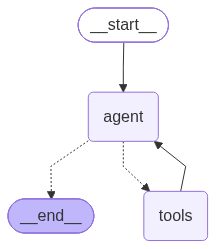

In [12]:
from IPython.display import Image,display

display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
for chunk in app.stream(
    {"messages":[("human","深圳的天气如何")]},stream_mode="values"
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

深圳的天气如何
================================== Ai Message ==================================
Tool Calls:
  get_weather (01a066726f91c2b0c1de310083fb4490)
 Call ID: 01a066726f91c2b0c1de310083fb4490
  Args:
    location: 深圳
================================= Tool Message =================================
Name: get_weather

现在是20度，有雾。
================================== Ai Message ==================================

深圳现在的天气是20度，有雾。


In [14]:
for chunk in app.stream(
    {"messages":[("human","最冷的天气如何")]},
    stream_mode="values"
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

最冷的天气如何
================================== Ai Message ==================================
Tool Calls:
  get_coolest_cities (01a06672915161150da6c33db78f537d)
 Call ID: 01a06672915161150da6c33db78f537d
  Args:
================================= Tool Message =================================
Name: get_coolest_cities

哈尔滨，北京
================================== Ai Message ==================================
Tool Calls:
  get_weather (01a0667298b944355f2eb8b72cbbcced)
 Call ID: 01a0667298b944355f2eb8b72cbbcced
  Args:
    location: 哈尔滨
  get_weather (01a0667298b944355f2eb8b72cbbccee)
 Call ID: 01a0667298b944355f2eb8b72cbbccee
  Args:
    location: 北京
================================= Tool Message =================================
Name: get_weather

现在是20度，有雾。
================================== Ai Message ==================================

目前查询到的最冷城市是哈尔滨，天气为10度，晴朗；而北京的天气为20度，有雾。因此，哈尔滨的天气更冷。
